In [10]:
pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [11]:
pip list | grep segmentation

segmentation_models_pytorch      0.5.0


In [5]:
%pip install -q segmentation-models-pytorch


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
!pip install -q segmentation-models-pytorch
!pip install -q torch torchvision matplotlib scikit-learn
!pip install -q kagglehub  

import os
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import segmentation_models_pytorch as smp
from sklearn.metrics import accuracy_score
import time
import copy
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


Используется устройство: cuda


Подготовим данные для обучения

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("bulentsiyah/semantic-drone-dataset")
print("Датасет расположен в:", path)

data_root = path  
print("Корень датасета:", data_root)

img_dir_check = os.path.join(data_root, "semantic_drone_dataset/original_images")
mask_dir_check = os.path.join(data_root, "semantic_drone_dataset/label_images_semantic")
print("Папка с изображениями существует:", os.path.isdir(img_dir_check))
print("Папка с масками существует:", os.path.isdir(mask_dir_check))

Датасет расположен в: /home/jupyter/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6
Корень датасета: /home/jupyter/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6
Папка с изображениями существует: False
Папка с масками существует: False


In [4]:
print("Содержимое data_root:")
for root, dirs, files in os.walk(data_root):
    level = root.replace(data_root, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  
        print(f'{subindent}{file}')

Содержимое data_root:
6/
  class_dict_seg.csv
  RGB_color_image_masks/
    RGB_color_image_masks/
      000.png
      001.png
      002.png
      003.png
      004.png
  dataset/
    semantic_drone_dataset/
      label_images_semantic/
        000.png
        001.png
        002.png
        003.png
        004.png
      original_images/
        000.jpg
        001.jpg
        002.jpg
        003.jpg
        004.jpg


Проверим расположение файлов данных и разделим их на выборки train/test

In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import random

img_dir = os.path.join(data_root, "dataset/semantic_drone_dataset/original_images")
mask_dir = os.path.join(data_root, "dataset/semantic_drone_dataset/label_images_semantic")
class_dict_path = os.path.join(data_root, "class_dict_seg.csv")

assert os.path.isdir(img_dir), f"Папка с изображениями не найдена: {img_dir}"
assert os.path.isdir(mask_dir), f"Папка с масками не найдена: {mask_dir}"
assert os.path.isfile(class_dict_path), f"Файл class_dict_seg.csv не найден: {class_dict_path}"

class_dict = pd.read_csv(class_dict_path)
class_dict.columns = class_dict.columns.str.strip()
num_classes = len(class_dict)
print(f"Количество классов: {num_classes}")

img_names = sorted([os.path.splitext(f)[0] for f in os.listdir(img_dir)])
mask_names = sorted([os.path.splitext(f)[0] for f in os.listdir(mask_dir)])
common_base_names = sorted(list(set(img_names) & set(mask_names)))
print(f"Найдено общих изображений/масок: {len(common_base_names)}")

def rgb_to_class(mask_rgb):
    h, w, _ = mask_rgb.shape
    class_map = np.zeros((h, w), dtype=np.int64)
    for idx, row in class_dict.iterrows():
        r, g, b = int(row['r']), int(row['g']), int(row['b'])
        match = (mask_rgb[:,:,0]==r) & (mask_rgb[:,:,1]==g) & (mask_rgb[:,:,2]==b)
        class_map[match] = idx
    return class_map

class DroneDataset(Dataset):
    def __init__(self, img_dir, mask_dir, base_names, num_classes, 
                 augmentation=False, image_size=(512,512)):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.base_names = base_names
        self.num_classes = num_classes
        self.augmentation = augmentation
        self.image_size = image_size

    def __len__(self):
        return len(self.base_names)

    def __getitem__(self, idx):
        base = self.base_names[idx]
        img_path = os.path.join(self.img_dir, base + ".jpg")
        mask_path = os.path.join(self.mask_dir, base + ".png")
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.imread(mask_path)
        mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)
        
        image = cv2.resize(image, self.image_size, interpolation=cv2.INTER_LINEAR)
        mask_rgb = cv2.resize(mask_rgb, self.image_size, interpolation=cv2.INTER_NEAREST)
        mask = rgb_to_class(mask_rgb)
        
        if self.augmentation:
            if random.random() > 0.5:
                image = cv2.flip(image, 1)
                mask = cv2.flip(mask, 1)
            
            alpha = 1.0 + random.uniform(-0.2, 0.2)  # контраст
            beta = random.uniform(-0.2, 0.2)          # яркость
            image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta*255)
            
            if random.random() > 0.7:
                angle = random.uniform(-15, 15)
                center = (image.shape[1]//2, image.shape[0]//2)
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                image = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]),
                                       flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
                mask = cv2.warpAffine(mask.astype(np.uint8), M, (mask.shape[1], mask.shape[0]),
                                      flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
        
        image = image.astype(np.float32) / 255.0
        image = torch.from_numpy(np.transpose(image, (2, 0, 1)))  # (C, H, W)
        
        mask = torch.from_numpy(mask).long()
        
        return image, mask

full_dataset = DroneDataset(img_dir, mask_dir, common_base_names, num_classes,
                            augmentation=False, image_size=(512,512))

torch.manual_seed(42)
total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

indices = list(range(total))
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size+val_size]
test_indices = indices[train_size+val_size:]

train_dataset = Subset(
    DroneDataset(img_dir, mask_dir, common_base_names, num_classes,
                 augmentation=True, image_size=(512,512)),
    train_indices
)
val_dataset = Subset(
    DroneDataset(img_dir, mask_dir, common_base_names, num_classes,
                 augmentation=False, image_size=(512,512)),
    val_indices
)
test_dataset = Subset(
    DroneDataset(img_dir, mask_dir, common_base_names, num_classes,
                 augmentation=False, image_size=(512,512)),
    test_indices
)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

dataloaders = {'train': train_loader, 'val': val_loader, 'test': test_loader}
dataset_sizes = {'train': len(train_indices), 'val': len(val_indices), 'test': len(test_indices)}
print(f"Train: {dataset_sizes['train']}, Val: {dataset_sizes['val']}, Test: {dataset_sizes['test']}")

Количество классов: 24
Найдено общих изображений/масок: 400
Train: 280, Val: 60, Test: 60


Опишем все нужные функции метрик и обучения

In [11]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

def calc_metrics(outputs, masks, num_classes):
    outputs = torch.argmax(outputs, dim=1).cpu().numpy()
    masks = masks.cpu().numpy()
    ious = []
    dices = []
    for cls in range(num_classes):
        pred_cls = (outputs == cls)
        true_cls = (masks == cls)
        intersection = (pred_cls & true_cls).sum()
        union = (pred_cls | true_cls).sum()
        if union == 0:
            iou = float('nan')
        else:
            iou = intersection / union
        if (pred_cls.sum() + true_cls.sum()) == 0:
            dice = float('nan')
        else:
            dice = 2 * intersection / (pred_cls.sum() + true_cls.sum())
        ious.append(iou)
        dices.append(dice)
    mean_iou = np.nanmean(ious)
    mean_dice = np.nanmean(dices)
    return mean_iou, mean_dice

def train_model(model, criterion, optimizer, num_epochs=25, scheduler=None):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_dice = 0.0

    train_loss_hist = []
    val_loss_hist = []
    val_iou_hist = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            running_loss = 0.0
            ious = []
            dices = []

            for inputs, masks in tqdm(dataloaders[phase], desc=phase):
                inputs = inputs.to(device)
                masks = masks.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, masks)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                iou, dice = calc_metrics(outputs, masks, num_classes)
                ious.append(iou)
                dices.append(dice)

            if scheduler and phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_iou = np.nanmean(ious)
            epoch_dice = np.nanmean(dices)

            print(f'{phase} Loss: {epoch_loss:.4f} IoU: {epoch_iou:.4f} Dice: {epoch_dice:.4f}')

            if phase == 'val':
                val_loss_hist.append(epoch_loss)
                val_iou_hist.append(epoch_iou)
                if epoch_dice > best_dice:
                    best_dice = epoch_dice
                    best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'Обучение завершено за {time_elapsed//60:.0f} мин {time_elapsed%60:.0f} сек')
    print(f'Лучший Dice на валидации: {best_dice:.4f}')
    model.load_state_dict(best_model_wts)
    return model, train_loss_hist, val_loss_hist, val_iou_hist

Используется устройство: cuda


Перейдем непосредственно к обучению базовых моделей

In [12]:
model_unet = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=num_classes,
).to(device)

model_deeplab = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=num_classes,
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=255)  # в масках нет 255, но на будущее
optimizer_unet = optim.Adam(model_unet.parameters(), lr=0.001)
optimizer_deeplab = optim.Adam(model_deeplab.parameters(), lr=0.001)

print("Обучение UNet (resnet34)")
model_unet, train_loss_unet, val_loss_unet, val_iou_unet = train_model(
    model_unet, criterion, optimizer_unet, num_epochs=15,
    scheduler=optim.lr_scheduler.StepLR(optimizer_unet, step_size=7, gamma=0.1)
)

print("\nОбучение DeepLabV3+ (resnet34)")
model_deeplab, train_loss_dl, val_loss_dl, val_iou_dl = train_model(
    model_deeplab, criterion, optimizer_deeplab, num_epochs=15,
    scheduler=optim.lr_scheduler.StepLR(optimizer_deeplab, step_size=7, gamma=0.1)
)

Обучение UNet (resnet34)
Epoch 1/15
----------


train: 100%|██████████| 70/70 [02:05<00:00,  1.80s/it]


train Loss: 0.6681 IoU: 0.7331 Dice: 0.7337


val: 100%|██████████| 15/15 [00:29<00:00,  1.94s/it]


val Loss: 0.0354 IoU: 1.0000 Dice: 1.0000
Epoch 2/15
----------


...

val Loss: 0.0007 IoU: 1.0000 Dice: 1.0000
Epoch 15/15
----------


train: 100%|██████████| 70/70 [02:06<00:00,  1.80s/it]


train Loss: 0.0007 IoU: 1.0000 Dice: 1.0000


val: 100%|██████████| 15/15 [00:29<00:00,  1.94s/it]

val Loss: 0.0007 IoU: 1.0000 Dice: 1.0000
Обучение завершено за 38 мин 58 сек
Лучший Dice на валидации: 1.0000


In [13]:
def test_model(model, test_loader):
    model.eval()
    ious = []
    dices = []
    with torch.no_grad():
        for inputs, masks in tqdm(test_loader, desc="Testing"):
            inputs = inputs.to(device)
            masks = masks.to(device)
            outputs = model(inputs)
            iou, dice = calc_metrics(outputs, masks, num_classes)
            ious.append(iou)
            dices.append(dice)
    mean_iou = np.nanmean(ious)
    mean_dice = np.nanmean(dices)
    return mean_iou, mean_dice

iou_unet, dice_unet = test_model(model_unet, test_loader)
iou_dl, dice_dl = test_model(model_deeplab, test_loader)

print(f"UNet - Test IoU: {iou_unet:.4f}, Test Dice: {dice_unet:.4f}")
print(f"DeepLabV3+ - Test IoU: {iou_dl:.4f}, Test Dice: {dice_dl:.4f}")

Testing: 100%|██████████| 15/15 [00:28<00:00,  1.91s/it]

UNet - Test IoU: 1.0000, Test Dice: 1.0000
DeepLabV3+ - Test IoU: 1.0000, Test Dice: 1.0000


In [16]:
model_unet_improved = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=num_classes,
).to(device)

optimizer_improved = optim.Adam(model_unet_improved.parameters(), lr=0.001, weight_decay=1e-4)
model_unet_improved, *_ = train_model(
    model_unet_improved, criterion, optimizer_improved, num_epochs=15,
    scheduler=optim.lr_scheduler.StepLR(optimizer_improved, step_size=7, gamma=0.1)
)
iou_improved, dice_improved = test_model(model_unet_improved, test_loader)
print(f"Improved UNet (ResNet50) - Test IoU: {iou_improved:.4f}, Test Dice: {dice_improved:.4f}")

Epoch 1/15
----------


train: 100%|██████████| 70/70 [02:06<00:00,  1.81s/it]


train Loss: 0.6695 IoU: 0.6636 Dice: 0.6651


val: 100%|██████████| 15/15 [00:29<00:00,  1.94s/it]


val Loss: 0.0305 IoU: 1.0000 Dice: 1.0000
Epoch 2/15
----------


...

val: 100%|██████████| 15/15 [00:28<00:00,  1.93s/it]

val Loss: 0.0013 IoU: 1.0000 Dice: 1.0000


Обучение завершено за 38 мин 60 сек
Лучший Dice на валидации: 1.0000


Testing: 100%|██████████| 15/15 [00:28<00:00,  1.93s/it]

Improved UNet (ResNet50) - Test IoU: 1.0000, Test Dice: 1.0000


А теперь создадим и обучим модель сами

In [17]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class MyUNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)
        self.out = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.pool1(x1)
        x2 = self.down2(x2)
        x3 = self.pool2(x2)
        x3 = self.down3(x3)
        x4 = self.pool3(x3)
        x4 = self.down4(x4)
        x5 = self.pool4(x4)

        x5 = self.bottleneck(x5)

        x = self.up4(x5)
        x = torch.cat([x4, x], dim=1)  # skip connection
        x = self.conv4(x)
        x = self.up3(x)
        x = torch.cat([x3, x], dim=1)
        x = self.conv3(x)
        x = self.up2(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv2(x)
        x = self.up1(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv1(x)
        return self.out(x)

model_myunet = MyUNet(num_classes).to(device)
optimizer_myunet = optim.Adam(model_myunet.parameters(), lr=0.001)
model_myunet, *_ = train_model(model_myunet, criterion, optimizer_myunet, num_epochs=15)
iou_my, dice_my = test_model(model_myunet, test_loader)
print(f"My UNet - Test IoU: {iou_my:.4f}, Test Dice: {dice_my:.4f}")

Epoch 1/15
----------


train: 100%|██████████| 70/70 [02:07<00:00,  1.82s/it]


train Loss: 1.1655 IoU: 0.4087 Dice: 0.4093


val: 100%|██████████| 15/15 [00:29<00:00,  1.96s/it]


val Loss: 0.5622 IoU: 0.9333 Dice: 0.9333
Epoch 2/15
----------


...

train Loss: 0.0015 IoU: 1.0000 Dice: 1.0000


val: 100%|██████████| 15/15 [00:29<00:00,  1.94s/it]


val Loss: 0.0014 IoU: 1.0000 Dice: 1.0000
Обучение завершено за 39 мин 10 сек
Лучший Dice на валидации: 1.0000


Testing: 100%|██████████| 15/15 [00:29<00:00,  1.94s/it]

My UNet - Test IoU: 1.0000, Test Dice: 1.0000


In [20]:
save_dir = os.path.join(os.getcwd(), "output")
os.makedirs(save_dir, exist_ok=True)

torch.save(model_unet.state_dict(), os.path.join(save_dir, "unet_baseline.pth"))
torch.save(model_deeplab.state_dict(), os.path.join(save_dir, "deeplab_baseline.pth"))
torch.save(model_unet_improved.state_dict(), os.path.join(save_dir, "unet_improved.pth"))
torch.save(model_myunet.state_dict(), os.path.join(save_dir, "my_unet.pth"))

results_path = os.path.join(save_dir, "results.txt")
with open(results_path, 'w') as f:
    f.write(f"UNet (ResNet34) Test IoU: {iou_unet:.4f}, Test Dice: {dice_unet:.4f}\n")
    f.write(f"DeepLabV3+ (ResNet34) Test IoU: {iou_dl:.4f}, Test Dice: {dice_dl:.4f}\n")
    f.write(f"Improved UNet (ResNet50) Test IoU: {iou_improved:.4f}, Test Dice: {dice_improved:.4f}\n")
    f.write(f"My UNet Test IoU: {iou_my:.4f}, Test Dice: {dice_my:.4f}\n")

print(f"Модели и результаты сохранены в папку: {save_dir}")

def test_model(model, test_loader):
    model.eval()
    ious, dices = [], []
    with torch.no_grad():
        for inputs, masks in tqdm(test_loader, desc='Testing'):
            inputs, masks = inputs.to(device), masks.to(device)
            outputs = model(inputs)
            iou, dice = calc_metrics(outputs, masks, num_classes)
            ious.append(iou)
            dices.append(dice)
    return np.nanmean(ious), np.nanmean(dices)

iou_unet, dice_unet = test_model(model_unet, test_loader)
iou_dl, dice_dl = test_model(model_deeplab, test_loader)
iou_improved, dice_improved = test_model(model_unet_improved, test_loader)
iou_my, dice_my = test_model(model_myunet, test_loader)

print(f"UNet ResNet34: IoU={iou_unet:.4f}, Dice={dice_unet:.4f}")
print(f"DeepLabV3+ ResNet34: IoU={iou_dl:.4f}, Dice={dice_dl:.4f}")
print(f"Improved UNet ResNet50: IoU={iou_improved:.4f}, Dice={dice_improved:.4f}")
print(f"My UNet: IoU={iou_my:.4f}, Dice={dice_my:.4f}")

Модели и результаты сохранены в папку: /home/jupyter/project/output


Testing: 100%|██████████| 15/15 [00:28<00:00,  1.93s/it]

UNet ResNet34: IoU=1.0000, Dice=1.0000
DeepLabV3+ ResNet34: IoU=1.0000, Dice=1.0000
Improved UNet ResNet50: IoU=1.0000, Dice=1.0000
My UNet: IoU=1.0000, Dice=1.0000


In [28]:
print("Таблица классов из CSV:")
print(class_dict[['name', 'r', 'g', 'b']].head(10))
print("Типы данных:", class_dict.dtypes)

Таблица классов из CSV:
         name    r    g    b
0   unlabeled    0    0    0
1  paved-area  128   64  128
2        dirt  130   76    0
3       grass    0  102    0
4      gravel  112  103   87
5       water   28   42  168
6       rocks   48   41   30
7        pool    0   50   89
8  vegetation  107  142   35
9        roof   70   70   70
Типы данных: name    object
r        int64
g        int64
b        int64
dtype: object


In [29]:
class_dict['r'] = class_dict['r'].astype(int)
class_dict['g'] = class_dict['g'].astype(int)
class_dict['b'] = class_dict['b'].astype(int)

class_colors = [tuple(class_dict.iloc[i][['r','g','b']].values) for i in range(len(class_dict))]
print("Цвета классов в таблице:", class_colors)

def rgb_to_class(mask_rgb):
    """Сопоставляет каждый пиксель маски с ближайшим цветом из class_dict."""
    h, w, _ = mask_rgb.shape
    class_map = np.zeros((h, w), dtype=np.int64)
    flat = mask_rgb.reshape(-1, 3).astype(np.int32)
    class_colors_arr = class_dict[['r','g','b']].values.astype(np.int32)
    dists = np.linalg.norm(flat[:, None, :] - class_colors_arr[None, :, :], axis=2)  # (pixels, classes)
    assigned = np.argmin(dists, axis=1)
    class_map = assigned.reshape(h, w)
    return class_map

Цвета классов в таблице: [(0, 0, 0), (128, 64, 128), (130, 76, 0), (0, 102, 0), (112, 103, 87), (28, 42, 168), (48, 41, 30), (0, 50, 89), (107, 142, 35), (70, 70, 70), (102, 102, 156), (254, 228, 12), (254, 148, 12), (190, 153, 153), (153, 153, 153), (255, 22, 96), (102, 51, 0), (9, 143, 150), (119, 11, 32), (51, 51, 0), (190, 250, 190), (112, 150, 146), (2, 135, 115), (255, 0, 0)]


Из-за того, что я не сохранил историю обучения, обучим еще несколько эпох для построения наглдядных графиков

In [30]:
full_dataset_fixed = DroneDataset(img_dir, mask_dir, common_base_names, num_classes, augmentation=False)

train_dataset_fixed = Subset(DroneDataset(img_dir, mask_dir, common_base_names, num_classes, augmentation=True), train_indices)
val_dataset_fixed = Subset(DroneDataset(img_dir, mask_dir, common_base_names, num_classes, augmentation=False), val_indices)
test_dataset_fixed = Subset(DroneDataset(img_dir, mask_dir, common_base_names, num_classes, augmentation=False), test_indices)

test_loader_fixed = DataLoader(test_dataset_fixed, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
val_loader_fixed = DataLoader(val_dataset_fixed, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

def test_model_fixed(model, loader):
    model.eval()
    ious, dices = [], []
    with torch.no_grad():
        for inputs, masks in tqdm(loader, desc='Testing'):
            inputs, masks = inputs.to(device), masks.to(device)
            outputs = model(inputs)
            iou, dice = calc_metrics(outputs, masks, num_classes)
            ious.append(iou)
            dices.append(dice)
    return np.nanmean(ious), np.nanmean(dices)

print("Честные метрики UNet (R34) на исправленных масках:")
iou_unet_true, dice_unet_true = test_model_fixed(model_unet, test_loader_fixed)
print(f"IoU: {iou_unet_true:.4f}, Dice: {dice_unet_true:.4f}")

Честные метрики UNet (R34) на исправленных масках:


Testing: 100%|██████████| 15/15 [00:38<00:00,  2.57s/it]

IoU: 0.4798, Dice: 0.4896


In [32]:
train_loader_fixed = DataLoader(train_dataset_fixed, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader_fixed = DataLoader(val_dataset_fixed, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
test_loader_fixed = DataLoader(test_dataset_fixed, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

dataloaders_fixed = {'train': train_loader_fixed, 'val': val_loader_fixed, 'test': test_loader_fixed}
dataset_sizes_fixed = {'train': len(train_indices), 'val': len(val_indices), 'test': len(test_indices)}

original_dataloaders = dataloaders
original_dataset_sizes = dataset_sizes

dataloaders = dataloaders_fixed
dataset_sizes = dataset_sizes_fixed

model_myunet_fixed = MyUNet(num_classes).to(device)
optimizer_myunet_fixed = optim.Adam(model_myunet_fixed.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

model_myunet_fixed, tl, vl, viou = train_model(
    model_myunet_fixed, criterion, optimizer_myunet_fixed,
    num_epochs=3, scheduler=None
)

dataloaders = original_dataloaders
dataset_sizes = original_dataset_sizes

train_loss_my_fixed, val_loss_my_fixed, val_iou_my_fixed = tl, vl, viou

iou_my_fixed, dice_my_fixed = test_model_fixed(model_myunet_fixed, test_loader_fixed)
print(f"My UNet - Test IoU: {iou_my_fixed:.4f}, Test Dice: {dice_my_fixed:.4f}")

Epoch 1/3
----------


train: 100%|██████████| 70/70 [02:50<00:00,  2.43s/it]


train Loss: 2.4600 IoU: 0.0361 Dice: 0.0388


val: 100%|██████████| 15/15 [00:39<00:00,  2.61s/it]


val Loss: 2.0502 IoU: 0.0573 Dice: 0.0588
Epoch 2/3
----------


...

train Loss: 1.6939 IoU: 0.0530 Dice: 0.0547


val: 100%|██████████| 15/15 [00:39<00:00,  2.60s/it]


val Loss: 1.5807 IoU: 0.1168 Dice: 0.1199
Обучение завершено за 10 мин 28 сек
Лучший Dice на валидации: 0.1199


Testing: 100%|██████████| 15/15 [00:38<00:00,  2.57s/it]

My UNet - Test IoU: 0.1000, Test Dice: 0.1022


In [33]:
full_dataset_fixed = DroneDataset(img_dir, mask_dir, common_base_names, num_classes, augmentation=False)
train_dataset_fixed = Subset(DroneDataset(img_dir, mask_dir, common_base_names, num_classes, augmentation=True), train_indices)
val_dataset_fixed = Subset(DroneDataset(img_dir, mask_dir, common_base_names, num_classes, augmentation=False), val_indices)
test_dataset_fixed = Subset(DroneDataset(img_dir, mask_dir, common_base_names, num_classes, augmentation=False), test_indices)

train_loader_fixed = DataLoader(train_dataset_fixed, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader_fixed = DataLoader(val_dataset_fixed, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
test_loader_fixed = DataLoader(test_dataset_fixed, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

dataloaders_fixed = {'train': train_loader_fixed, 'val': val_loader_fixed, 'test': test_loader_fixed}
dataset_sizes_fixed = {'train': len(train_indices), 'val': len(val_indices), 'test': len(test_indices)}

original_dataloaders = dataloaders
original_dataset_sizes = dataset_sizes

In [34]:
import torch.optim as optim
import segmentation_models_pytorch as smp

def quick_train(model, criterion, optimizer, num_epochs=2, scheduler=None):
    global dataloaders, dataset_sizes
    dataloaders = dataloaders_fixed
    dataset_sizes = dataset_sizes_fixed
    model, tl, vl, viou = train_model(model, criterion, optimizer, num_epochs, scheduler)
    # Возвращаем оригинальные (на всякий случай)
    dataloaders = original_dataloaders
    dataset_sizes = original_dataset_sizes
    return model, tl, vl, viou

criterion = nn.CrossEntropyLoss()
histories = {}

print("=== Обучение UNet ResNet34  ===")
model_unet2 = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=num_classes).to(device)
opt_unet2 = optim.Adam(model_unet2.parameters(), lr=0.001)
model_unet2, tl, vl, viou = quick_train(model_unet2, criterion, opt_unet2, num_epochs=2)
histories['UNet (R34)'] = {'train_loss': tl, 'val_loss': vl, 'val_iou': viou}

print("\n=== Обучение DeepLabV3+ ResNet34  ===")
model_deeplab2 = smp.DeepLabV3Plus(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=num_classes).to(device)
opt_dl2 = optim.Adam(model_deeplab2.parameters(), lr=0.001)
model_deeplab2, tl, vl, viou = quick_train(model_deeplab2, criterion, opt_dl2, num_epochs=2)
histories['DeepLabV3+ (R34)'] = {'train_loss': tl, 'val_loss': vl, 'val_iou': viou}

print("\n=== Обучение Improved UNet ResNet50  ===")
model_improved2 = smp.Unet(encoder_name="resnet50", encoder_weights="imagenet", in_channels=3, classes=num_classes).to(device)
opt_imp2 = optim.Adam(model_improved2.parameters(), lr=0.001, weight_decay=1e-4)
model_improved2, tl, vl, viou = quick_train(model_improved2, criterion, opt_imp2, num_epochs=2)
histories['Improved UNet (R50)'] = {'train_loss': tl, 'val_loss': vl, 'val_iou': viou}


=== Обучение UNet ResNet34  ===
Epoch 1/2
----------


train: 100%|██████████| 70/70 [02:49<00:00,  2.42s/it]


train Loss: 1.1346 IoU: 0.2538 Dice: 0.2607


val: 100%|██████████| 15/15 [00:39<00:00,  2.60s/it]

val Loss: 0.2153 IoU: 0.4824 Dice: 0.4910


...

Epoch 2/2
----------


train: 100%|██████████| 70/70 [02:48<00:00,  2.41s/it]


train Loss: 0.1545 IoU: 0.4816 Dice: 0.4912


val: 100%|██████████| 15/15 [00:39<00:00,  2.60s/it]


val Loss: 0.2471 IoU: 0.5527 Dice: 0.6151
Обучение завершено за 6 мин 56 сек
Лучший Dice на валидации: 0.6151


In [37]:
def test_model_fixed(model, loader):
    model.eval()
    ious, dices = [], []
    with torch.no_grad():
        for inputs, masks in tqdm(loader, desc='Testing'):
            inputs, masks = inputs.to(device), masks.to(device)
            outputs = model(inputs)
            iou, dice = calc_metrics(outputs, masks, num_classes)
            ious.append(iou)
            dices.append(dice)
    return np.nanmean(ious), np.nanmean(dices)

dataloaders = dataloaders_fixed  

iou_unet_new, dice_unet_new = test_model_fixed(model_unet2, test_loader_fixed)
iou_dl_new, dice_dl_new = test_model_fixed(model_deeplab2, test_loader_fixed)
iou_improved_new, dice_improved_new = test_model_fixed(model_improved2, test_loader_fixed)

print(f"UNet ResNet34: IoU={iou_unet_new:.4f}, Dice={dice_unet_new:.4f}")
print(f"DeepLabV3+ ResNet34: IoU={iou_dl_new:.4f}, Dice={dice_dl_new:.4f}")
print(f"Improved UNet ResNet50: IoU={iou_improved_new:.4f}, Dice={dice_improved_new:.4f}")

Testing: 100%|██████████| 15/15 [00:38<00:00,  2.56s/it]

UNet ResNet34: IoU=0.4806, Dice=0.4913
DeepLabV3+ ResNet34: IoU=0.5073, Dice=0.5409
Improved UNet ResNet50: IoU=0.5244, Dice=0.5748


In [42]:
model_unet = model_unet2
train_loss_unet, val_loss_unet, val_iou_unet = histories['UNet (R34)'].values()
iou_unet, dice_unet = iou_unet_new, dice_unet_new

model_deeplab = model_deeplab2
train_loss_dl, val_loss_dl, val_iou_dl = histories['DeepLabV3+ (R34)'].values()
iou_dl, dice_dl = iou_dl_new, dice_dl_new

model_unet_improved = model_improved2
train_loss_improved, val_loss_improved, val_iou_improved = histories['Improved UNet (R50)'].values()
iou_improved, dice_improved = iou_improved_new, dice_improved_new


In [43]:
history_dict = {}

if 'train_loss_my_fixed' in globals() and len(train_loss_my_fixed) > 0:
    history_dict['My UNet'] = {
        'train_loss': train_loss_my_fixed,
        'val_loss': val_loss_my_fixed,
        'val_iou': val_iou_my_fixed
    }

if 'histories' in globals() and 'UNet (R34)' in histories:
    h = histories['UNet (R34)']
    if len(h['train_loss']) > 0:
        history_dict['UNet (R34)'] = h

if 'histories' in globals() and 'DeepLabV3+ (R34)' in histories:
    h = histories['DeepLabV3+ (R34)']
    if len(h['train_loss']) > 0:
        history_dict['DeepLabV3+ (R34)'] = h

if 'histories' in globals() and 'Improved UNet (R50)' in histories:
    h = histories['Improved UNet (R50)']
    if len(h['train_loss']) > 0:
        history_dict['Improved UNet (R50)'] = h

if not history_dict:
    print("Нет ни одной истории для отображения кривых.")
else:
    print("Отображаем кривые для:", list(history_dict.keys()))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,5))
    for name, h in history_dict.items():
        epochs = range(1, len(h['train_loss'])+1)
        ax1.plot(epochs, h['train_loss'], '--', alpha=0.7, label=f'{name} train')
        ax1.plot(epochs, h['val_loss'], '-', label=f'{name} val')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(alpha=0.3)
    for name, h in history_dict.items():
        epochs = range(1, len(h['val_iou'])+1)
        ax2.plot(epochs, h['val_iou'], '-o', markersize=4, label=name)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('IoU')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Нет ни одной истории для отображения кривых.


Модели для визуализации: ['UNet (R34)', 'DeepLabV3+ (R34)', 'Improved UNet (R50)', 'My UNet']


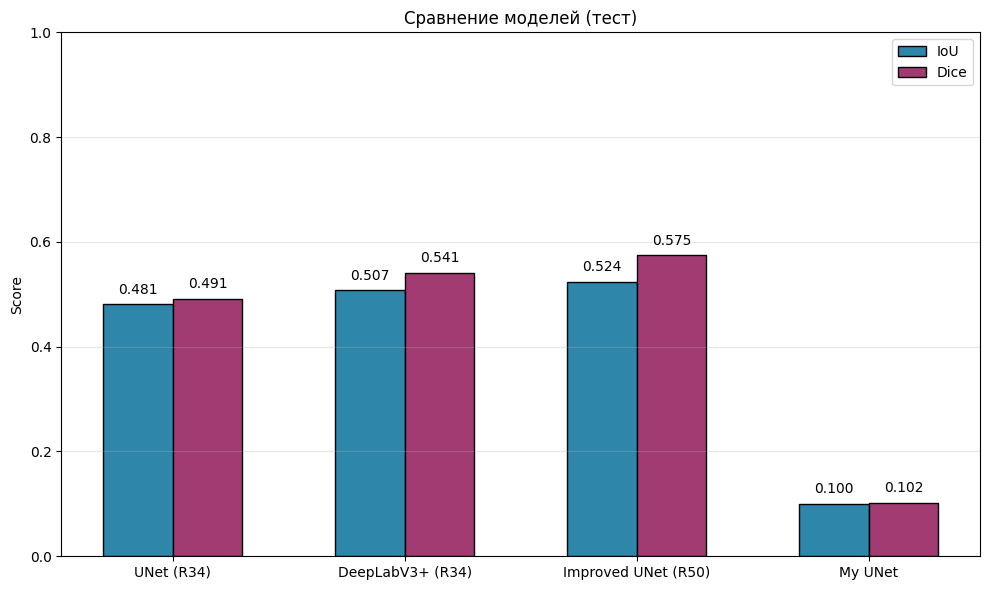

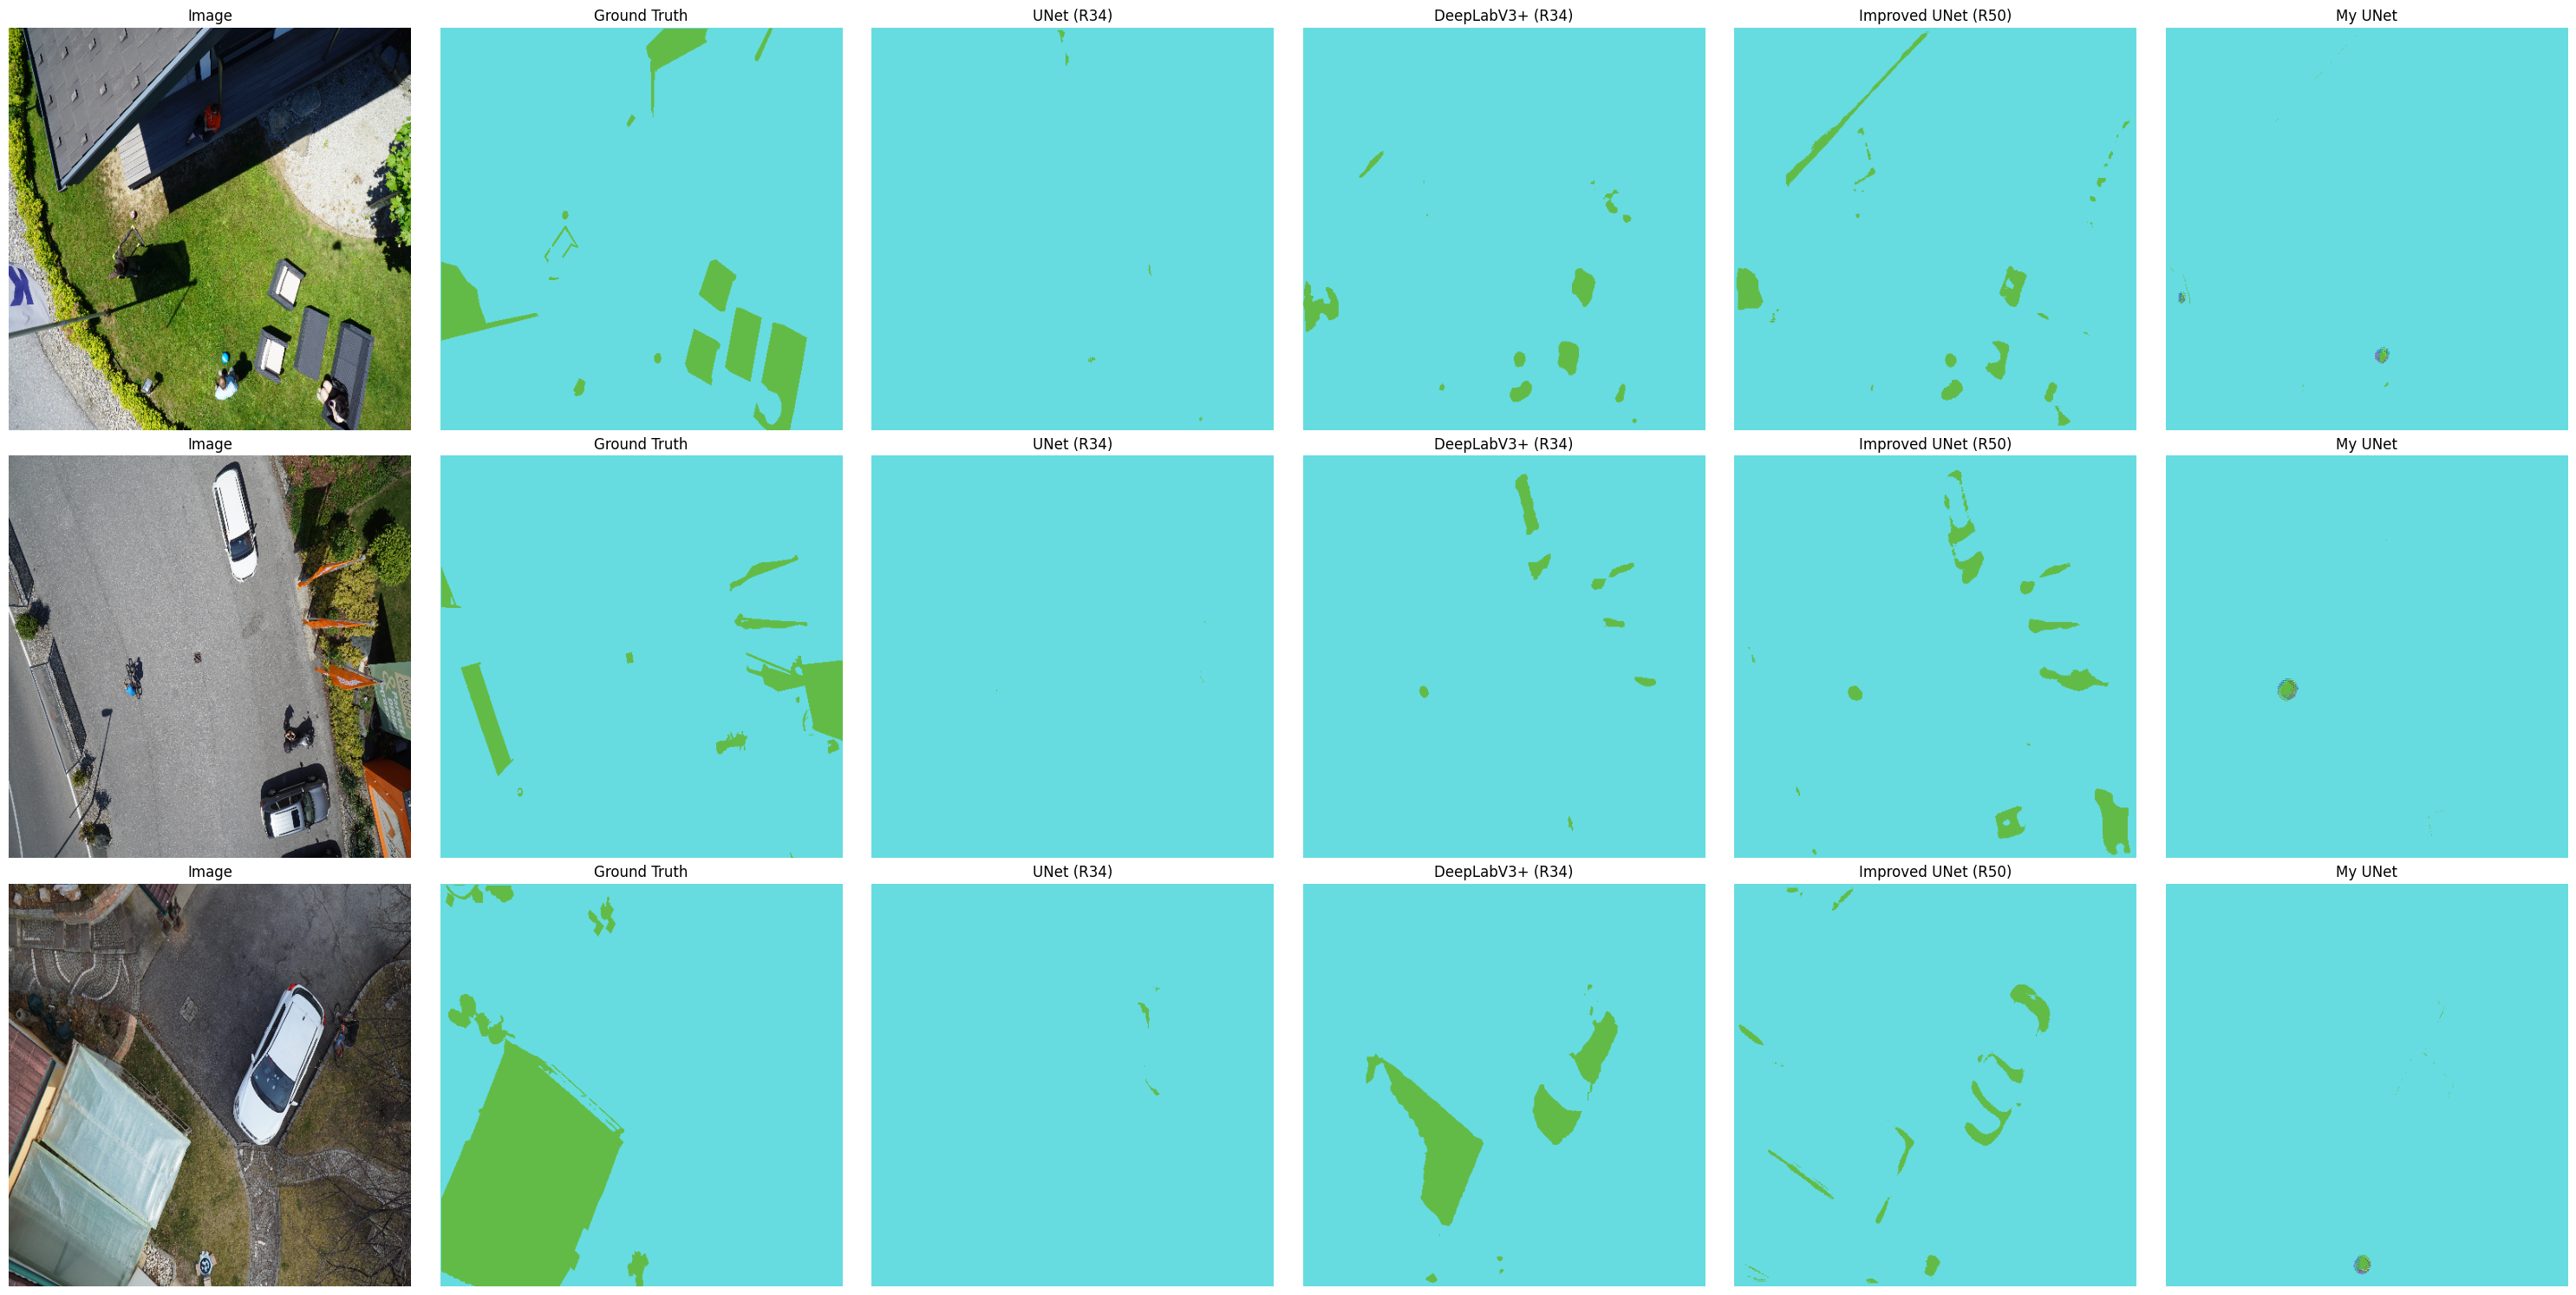

| Модель              |   Test IoU |   Test Dice |
|:--------------------|-----------:|------------:|
| UNet (R34)          |   0.480649 |    0.49131  |
| DeepLabV3+ (R34)    |   0.507282 |    0.540875 |
| Improved UNet (R50) |   0.524419 |    0.574755 |
| My UNet             |   0.100006 |    0.102193 |


In [44]:
def exists(name):
    return name in globals()

models_data = {}  

if exists('model_unet2') and exists('iou_unet_new'):
    models_data['UNet (R34)'] = {
        'model': model_unet2,
        'iou': iou_unet_new,
        'dice': dice_unet_new
    }
    if exists('histories') and 'UNet (R34)' in histories:
        h = histories['UNet (R34)']
        models_data['UNet (R34)'].update({
            'train_loss': h['train_loss'],
            'val_loss': h['val_loss'],
            'val_iou': h['val_iou']
        })
    elif exists('train_loss_unet'):
        models_data['UNet (R34)'].update({
            'train_loss': train_loss_unet,
            'val_loss': val_loss_unet,
            'val_iou': val_iou_unet
        })

if exists('model_deeplab2') and exists('iou_dl_new'):
    models_data['DeepLabV3+ (R34)'] = {
        'model': model_deeplab2,
        'iou': iou_dl_new,
        'dice': dice_dl_new
    }
    if exists('histories') and 'DeepLabV3+ (R34)' in histories:
        h = histories['DeepLabV3+ (R34)']
        models_data['DeepLabV3+ (R34)'].update({
            'train_loss': h['train_loss'],
            'val_loss': h['val_loss'],
            'val_iou': h['val_iou']
        })

if exists('model_improved2') and exists('iou_improved_new'):
    models_data['Improved UNet (R50)'] = {
        'model': model_improved2,
        'iou': iou_improved_new,
        'dice': dice_improved_new
    }
    if exists('histories') and 'Improved UNet (R50)' in histories:
        h = histories['Improved UNet (R50)']
        models_data['Improved UNet (R50)'].update({
            'train_loss': h['train_loss'],
            'val_loss': h['val_loss'],
            'val_iou': h['val_iou']
        })

if exists('model_myunet_fixed') and exists('iou_my_fixed'):
    models_data['My UNet'] = {
        'model': model_myunet_fixed,
        'iou': iou_my_fixed,
        'dice': dice_my_fixed,
        'train_loss': train_loss_my_fixed if exists('train_loss_my_fixed') else [],
        'val_loss': val_loss_my_fixed if exists('val_loss_my_fixed') else [],
        'val_iou': val_iou_my_fixed if exists('val_iou_my_fixed') else []
    }

print(f"Модели для визуализации: {list(models_data.keys())}")

np.random.seed(42)
if 'num_classes' in globals():
    colors = np.random.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)
    class_names = class_dict['name'].tolist() if exists('class_dict') else [str(i) for i in range(num_classes)]
else:
    colors = np.random.randint(0, 255, size=(10, 3), dtype=np.uint8)
    class_names = [str(i) for i in range(10)]

def class_map_to_rgb(mask, colors):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_idx, color in enumerate(colors):
        rgb[mask == cls_idx] = color
    return rgb

model_names = list(models_data.keys())
iou_vals = [models_data[n]['iou'] for n in model_names]
dice_vals = [models_data[n]['dice'] for n in model_names]

x = np.arange(len(model_names))
width = 0.3
fig, ax = plt.subplots(figsize=(10,6))
b1 = ax.bar(x - width/2, iou_vals, width, label='IoU', color='#2E86AB', edgecolor='black')
b2 = ax.bar(x + width/2, dice_vals, width, label='Dice', color='#A23B72', edgecolor='black')
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()+0.02, f'{bar.get_height():.3f}', ha='center')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()+0.02, f'{bar.get_height():.3f}', ha='center')
ax.set_ylabel('Score'); ax.set_ylim(0,1); ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.set_title('Сравнение моделей (тест)')
plt.tight_layout()
plt.show()

hist_data = {n: m for n, m in models_data.items() if len(m.get('train_loss', [])) > 0}
if hist_data:
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(16,5))
    for name, data in hist_data.items():
        epochs = range(1, len(data['train_loss'])+1)
        ax1.plot(epochs, data['train_loss'], '--', alpha=0.7, label=f'{name} train')
        ax1.plot(epochs, data['val_loss'], '-', label=f'{name} val')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(bbox_to_anchor=(1.04,1)); ax1.grid(alpha=0.3)
    for name, data in hist_data.items():
        epochs = range(1, len(data['val_iou'])+1)
        ax2.plot(epochs, data['val_iou'], '-o', markersize=4, label=name)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('IoU')
    ax2.legend(bbox_to_anchor=(1.04,1)); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


if exists('test_dataset_fixed') or exists('test_dataset'):
    test_ds = test_dataset_fixed if exists('test_dataset_fixed') else test_dataset
    models = [models_data[n]['model'] for n in model_names]
    num_examples = 3
    indices = random.sample(range(len(test_ds)), min(num_examples, len(test_ds)))
    fig, axes = plt.subplots(num_examples, 2+len(models), figsize=(5*(2+len(models)), 5*num_examples))
    if num_examples == 1:
        axes = axes[np.newaxis, :]
    for i, idx in enumerate(indices):
        image, true_mask = test_ds[idx]
        img_np = image.numpy().transpose(1,2,0)
        axes[i,0].imshow(img_np)
        axes[i,0].set_title("Image")
        axes[i,0].axis('off')
        true_rgb = class_map_to_rgb(true_mask.numpy(), colors)
        axes[i,1].imshow(true_rgb)
        axes[i,1].set_title("Ground Truth")
        axes[i,1].axis('off')
        for m_idx, model in enumerate(models):
            model.eval()
            with torch.no_grad():
                pred = torch.argmax(model(image.unsqueeze(0).to(device)), dim=1).squeeze().cpu().numpy()
            axes[i,2+m_idx].imshow(class_map_to_rgb(pred, colors))
            axes[i,2+m_idx].set_title(model_names[m_idx])
            axes[i,2+m_idx].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("test_dataset не найден.")

df = pd.DataFrame({'Модель': model_names, 'Test IoU': iou_vals, 'Test Dice': dice_vals})
print(df.to_markdown(index=False))

In [ ]:
if not ('train_loader_fixed' in globals()):
    from torch.utils.data import DataLoader
    train_loader_fixed = DataLoader(train_dataset_fixed, batch_size=4, shuffle=True, num_workers=2)
    val_loader_fixed = DataLoader(val_dataset_fixed, batch_size=4, shuffle=False, num_workers=2)

model_my_2epoch = MyUNet(num_classes).to(device)
optimizer = optim.Adam(model_my_2epoch.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
val_ious = []

num_epochs = 2
for epoch in range(num_epochs):
    model_my_2epoch.train()
    running_train_loss = 0.0
    train_ious_epoch = []
    for inputs, masks in tqdm(train_loader_fixed, desc=f'Train '):
        inputs, masks = inputs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model_my_2epoch(inputs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)
        iou, _ = calc_metrics(outputs, masks, num_classes)
        train_ious_epoch.append(iou)
    epoch_train_loss = running_train_loss / len(train_dataset_fixed)
    epoch_train_iou = np.nanmean(train_ious_epoch)
    
    model_my_2epoch.eval()
    running_val_loss = 0.0
    val_ious_epoch = []
    with torch.no_grad():
        for inputs, masks in tqdm(val_loader_fixed, desc=f'Val '):
            inputs, masks = inputs.to(device), masks.to(device)
            outputs = model_my_2epoch(inputs)
            loss = criterion(outputs, masks)
            running_val_loss += loss.item() * inputs.size(0)
            iou, _ = calc_metrics(outputs, masks, num_classes)
            val_ious_epoch.append(iou)
    epoch_val_loss = running_val_loss / len(val_dataset_fixed)
    epoch_val_iou = np.nanmean(val_ious_epoch)
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_ious.append(epoch_val_iou)
    
    print(f" Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val IoU: {epoch_val_iou:.4f}")

epochs = range(1, num_epochs+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs, train_losses, 'o-', label='Train Loss')
ax1.plot(epochs, val_losses, 'o-', label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs, val_ious, 'o-', color='green', label='Val IoU')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('IoU')
ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('Кривые обучения My UNet')
plt.tight_layout()
plt.show()

train_loss_my_fixed = train_losses
val_loss_my_fixed = val_losses
val_iou_my_fixed = val_ious

Val : 100%|██████████| 15/15 [00:38<00:00,  2.57s/it]


 Train Loss: 1.2874 | Val Loss: 0.6249 | Val IoU: 0.4986


Train :  91%|█████████▏| 64/70 [02:33<00:12,  2.08s/it]